# Introduction


**File:** Notebook_IVP_fast_t_MC_tests.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 09.03.2026
\
**Problem:** Test our model for $k_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This contains my tests of my fast oscillation wave number model, compared to a random selection of points within my parameter ranges. The results appear to work great. Due to the random nature of this simulation, the exact results will not be the same each time.

# Building Grid

In [ ]:
#--LIBRARIES--------
import eelib

import numpy as np
import pickle
import pandas as pd

import seaborn as sns # statistical data visualization

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-7

n = 100000 # ~100000 = 12 hrs

b_r  = (0.03, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.1, 0.9)
mu_r = (1.0e-9, 3.0e-6) #1.0e-8 to 1.0e-5


In my old version of the code, the error was dependent on $R$. I therefore just fixed $R$ and rescaled $B$ instead. I believe the new version of the code fixes that problem, but I have maintained my old structure of parameters.

In [43]:
#--CODE--

#make loop, grid, or system
gridl = eelib.grid_fast_osc(R, B, dk, mu)

gridl.makeMCPoints(mu=mu_r, dk=dk_r, B=b_r, num = n)
gridl.mcFastOsc()

Begin grid build:  0.0
Number of periods to calculate: 10000
Done grid build:  7393.767033338547


Again, code to save or load these datasets, to prevent the need to rerun the code everytime.

In [ ]:
filename = 'grid104'

# Save the grid
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [3]:
filename = 'grid104'

#loading script; be careful of python version
file = open(filename, 'rb')    
gridl = pickle.load(file)
file.close()

And check that our object is what we expect.

In [4]:
gridl

Monte Carlo object to measure fast oscillations:
mu has points from 1.0250542210677182e-09 to 2.9999933820762313e-06.
dk has points from 0.10000549989647221 to 0.8999976272184045.
B has points from 0.030002709859695064 to 0.9999955284879901.
R has points from 1.0 to 1.0.
A has points from 1.0 to 1.0.
k0 has points from 12000000000.0 to 12000000000.0.
Number of points: 100000

# Testing Our Grid

In [20]:
# Pull the grids of values from our object

# independent variables
val_table = gridl.val_table

# dependent variables
fot = gridl.fast_osc_t

In [ ]:
# Here we are changing the format of variable storage.
# This is intended for use with pandas.
# Columns are parameter / variable values here.

npaf = np.zeros((n, 6))
npaf[:,0] = val_table[:,0]
npaf[:,1] = val_table[:,1]
npaf[:,2] = val_table[:,2]
npaf[:,3] = val_table[:,6]/ (val_table[:,5] + val_table[:,1]/R /2.0)
npaf[:,4] = val_table[:,7]/ (val_table[:,5] + val_table[:,1]/R /2.0)
npaf[:,5] = fot
for ii in range(n):
    npaf[ii,5] -= eelib.pred_fast_t(val_table[ii,6] + 1.j * val_table[ii,7], val_table[ii,0], val_table[ii,1], val_table[ii,2], val_table[ii,3])

In [7]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D real", "D imag", "T fast"])

# and to show it
dfa.head()

,mu,dk,B,D re,D im,T fast
0,1.203469e-06,0.556701,0.752390,-0.482929,-0.353262,2.739597e-17
1,1.546220e-06,0.376634,0.950932,0.705367,-0.900263,-3.366993e-17
2,7.648871e-07,0.308679,0.547938,-0.937154,0.262829,4.149815e-17
3,1.800016e-06,0.778896,0.221878,-1.149192,-0.816950,2.628770e-17
4,1.076170e-06,0.824707,0.331229,0.944530,1.153123,3.007029e-17


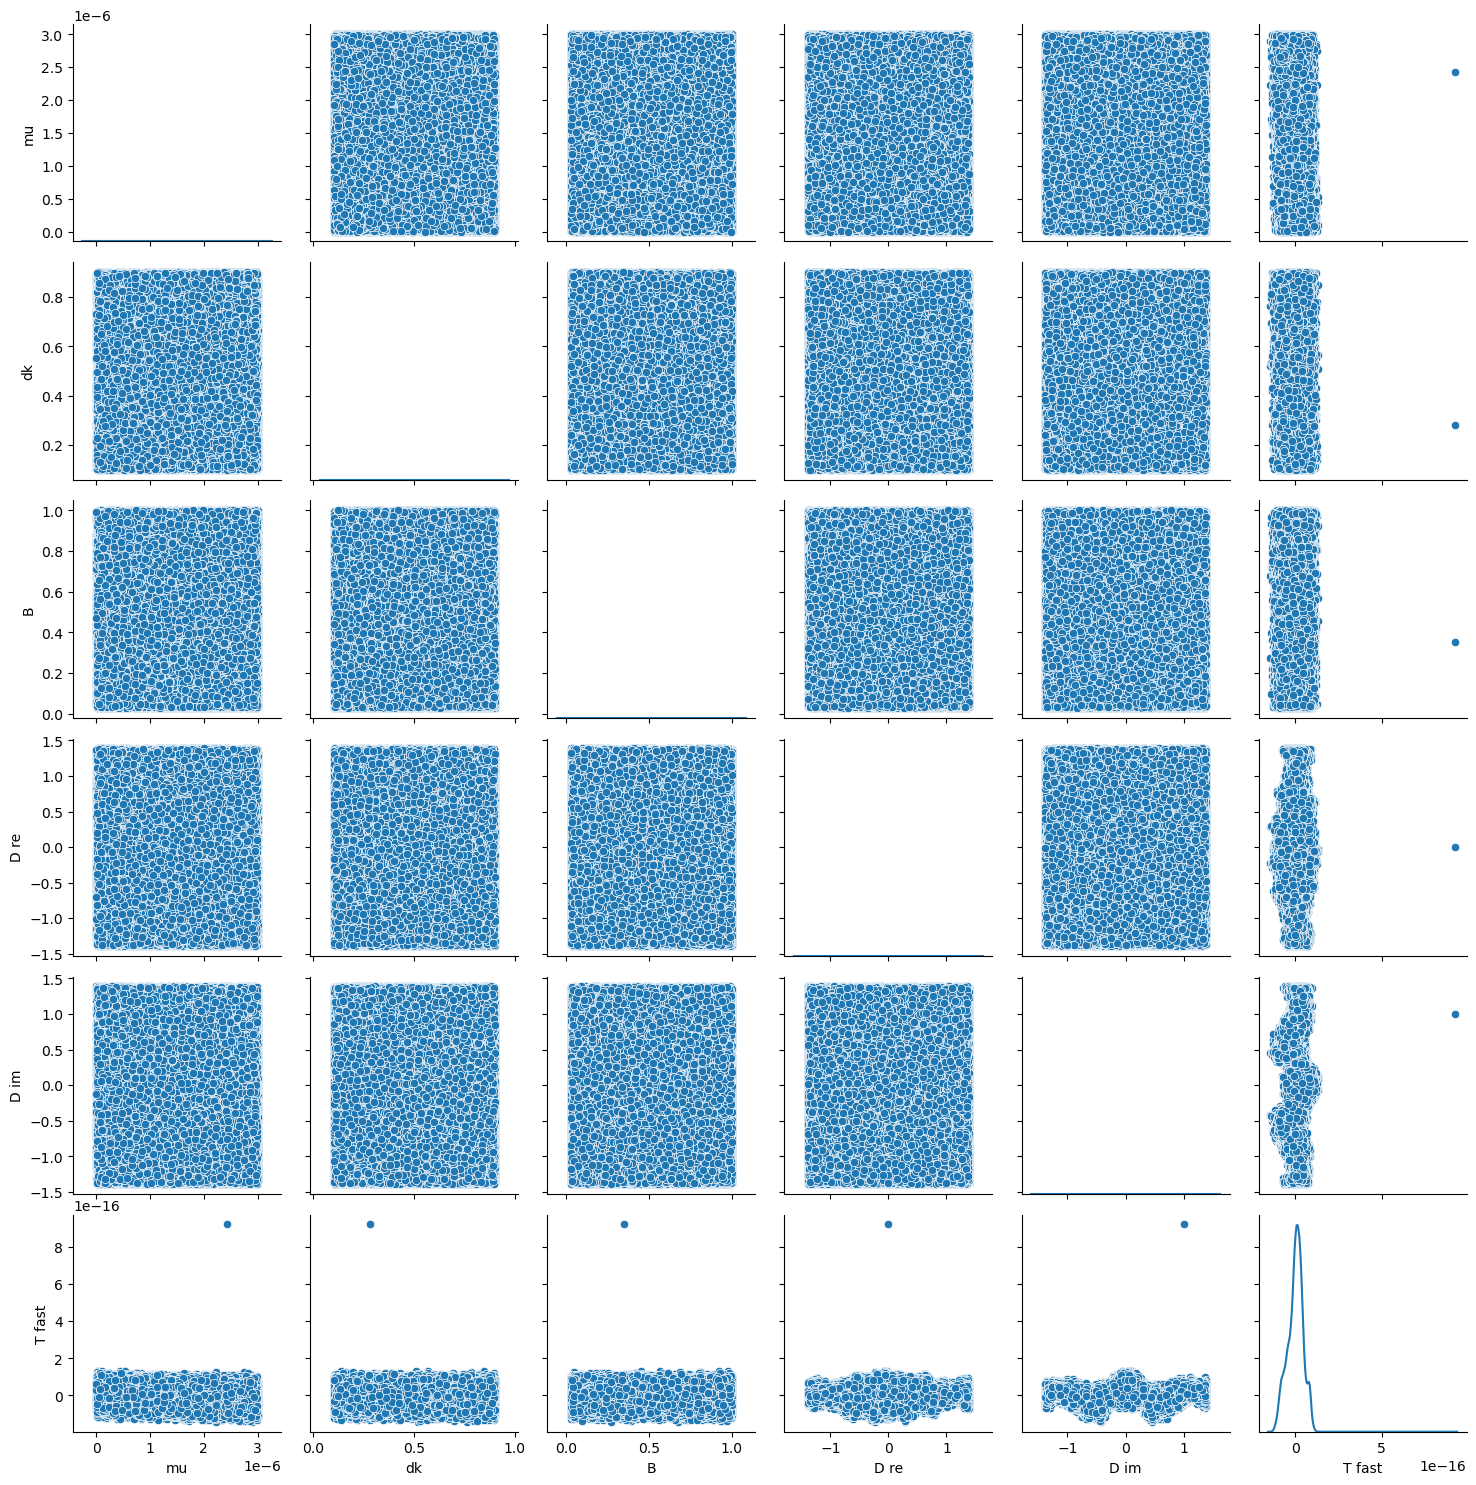

In [8]:
g = sns.PairGrid(dfa)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

Patterns in the data are no longer as easy to see due to the random nature of our data, except for the shape of the error in the last plot. Our model, however, appears to work well. There are definitely patterns in the data, they are just not so easy to pick out visually.

There is one point with a suspiciously large error. Everything else is within tolerance. Of note is $\mathrm{Re}(\psi^\prime_0)$ of this point is very close to 0. I had a point with very large error and $\mathrm{Re}(\psi^\prime_0) = 0$ in a previous run as well. This may be what is causing it.

# Finding Outliers

I will first determine my ranges of my difference between predicted and measured half period. Then I will pick out the points with the greatest error until I have reduced my dataset to only points within the expected error range. \
**Note:** This code will not produce consistent results for each run. 

In [9]:
np.max(npaf[:,5]), np.min(npaf[:,5])

(9.217153068210605e-16, -1.4314846034570197e-16)

My first outlier.

In [10]:
np.argmax(npaf[:,5])

94802

And now determine my remaining range.

In [11]:
np.min(npaf[:94802,5]), np.min(npaf[94802:,5])

(-1.4314846034570197e-16, -1.4002583373267838e-16)

Definitely only one point in 100000.

Here is the point.

In [12]:
npaf[94802]

array([2.42249083e-06, 2.79641532e-01, 3.51182498e-01, 5.53712604e-05,
       9.99584721e-01, 9.21715307e-16])